<a href="https://colab.research.google.com/github/K24-github/Batik-MobileNet-Yolo/blob/main/Batik_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q ultralytics roboflow
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras import layers, models, callbacks
from ultralytics import YOLO
from roboflow import Roboflow
from sklearn.metrics import classification_report, accuracy_score, f1_score
# v4 of the Roboflow project = the one with classes under 30 images dropped.
# Both models pull from this same export so neither gets a different split.
from google.colab import userdata
Roboflow_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=Roboflow_API_KEY)
project = rf.workspace("kevin-ndvek").project("batik-indonesia-classification-removedunder30")
version = project.version(4)
dataset = version.download("folder")
DATASET_PATH = dataset.location

TRAIN_PATH = f"{DATASET_PATH}/train"
VAL_PATH = f"{DATASET_PATH}/valid"
TEST_PATH = f"{DATASET_PATH}/test"

print(f"Dataset ready at: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to batik-indonesia-classification-removedunder30-4 in folder:: 100%|██████████| 2425/2425 [00:00<00:00, 6521.40it/s]

Dataset ready at: /content/batik-indonesia-classification-removedunder30-4



TOTAL DATASET DISTRIBUTION (TRAIN + VAL + TEST)

--- Combined Dataset Summary ---
Total Images: 2330
Total Classes: 30
Avg Images/Class: 77.7


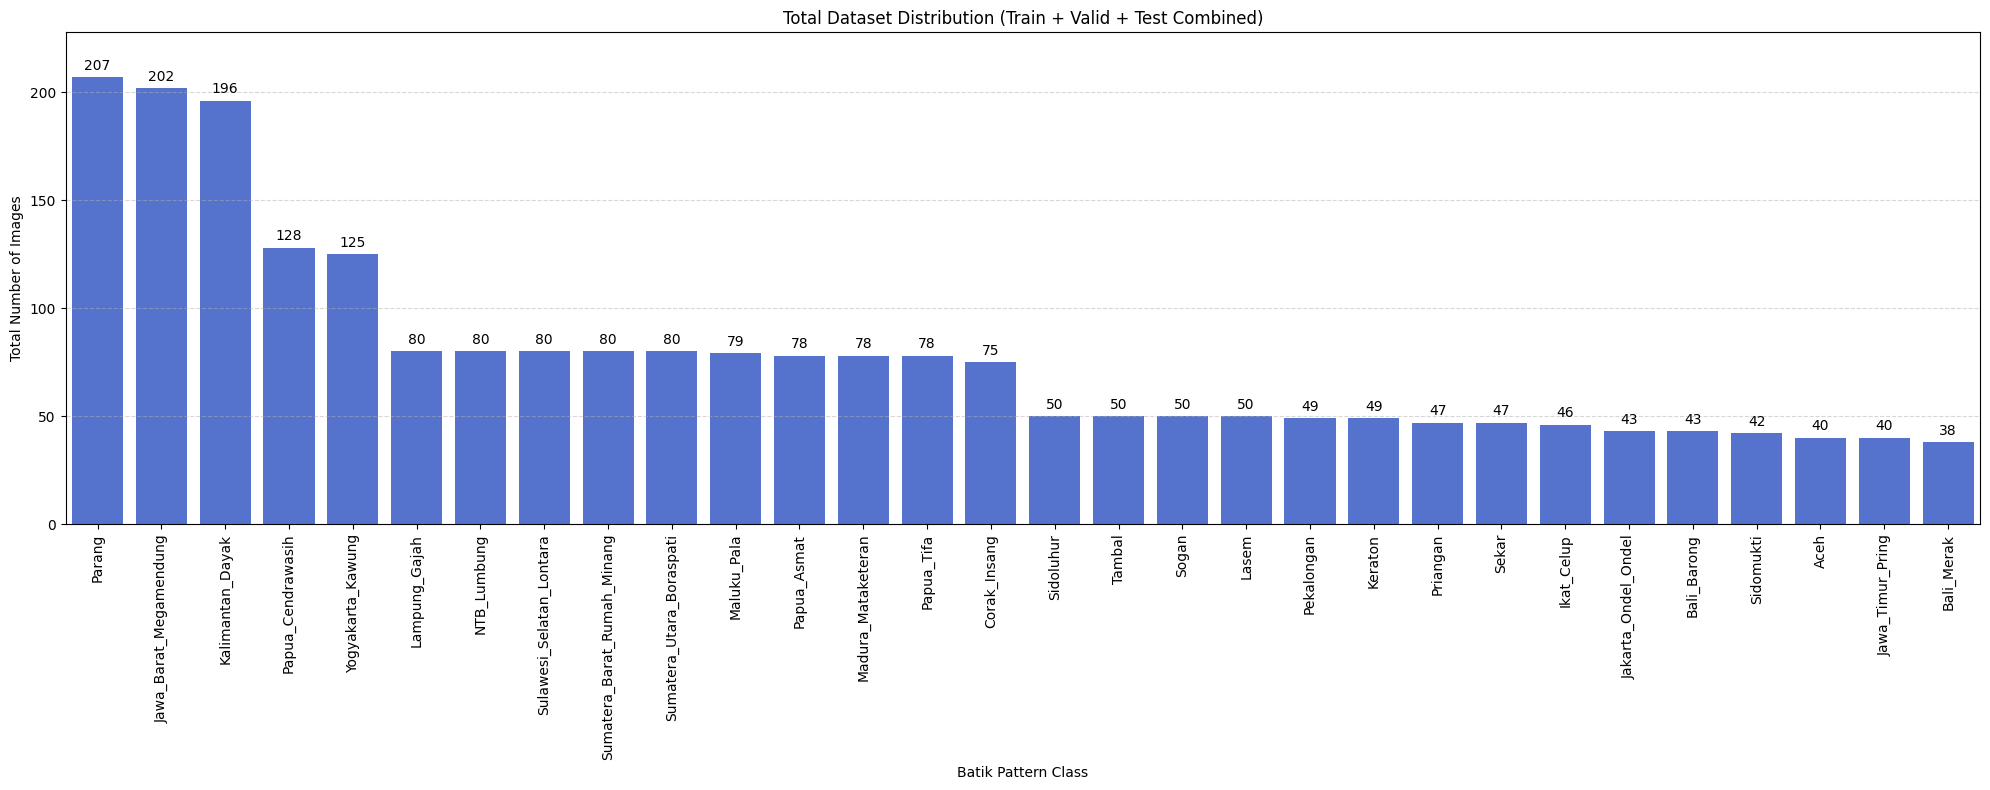

In [4]:
# Checking how skewed the classes are before training. Parang and Megamendung
# have ~200 images each while some regional motifs barely clear 40, so the
# macro-F1 later is going to matter more than plain accuracy.
print("\n" + "="*40)
print("TOTAL DATASET DISTRIBUTION (TRAIN + VAL + TEST)")
print("="*40)

def plot_combined_distribution(train_dir, val_dir, test_dir):
    class_counts = {}

    if not os.path.exists(train_dir):
        print(f"Directory not found: {train_dir}")
        return

    classes = sorted(os.listdir(train_dir))

    for class_name in classes:
        total_count = 0
        for split_path in [train_dir, val_dir, test_dir]:
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp'))])
                total_count += num_images
        class_counts[class_name] = total_count

    df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Total Count'])

    df = df.sort_values(by='Total Count', ascending=False)
    df = df.reset_index(drop=True)  # without this the count labels below land on the wrong bars

    print(f"\n--- Combined Dataset Summary ---")
    print(f"Total Images: {df['Total Count'].sum()}")
    print(f"Total Classes: {len(df)}")
    print(f"Avg Images/Class: {df['Total Count'].mean():.1f}")

    plt.figure(figsize=(20, 8))

    # one flat colour, the default rainbow palette just adds noise with 30 bars
    sns.barplot(data=df, x='Class', y='Total Count', color='royalblue')

    for index, row in df.iterrows():
        plt.text(index, row['Total Count'] + 2, str(row['Total Count']),
                 color='black', ha="center", va="bottom", fontsize=10)

    plt.xticks(rotation=90)
    plt.title(f"Total Dataset Distribution (Train + Valid + Test Combined)")
    plt.xlabel("Batik Pattern Class")
    plt.ylabel("Total Number of Images")

    plt.ylim(0, df['Total Count'].max() * 1.1)  # headroom so the top label isn't clipped

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_combined_distribution(TRAIN_PATH, VAL_PATH, TEST_PATH)

In [ ]:
import time

# Shared config. Keeping image size, batch, epochs, patience and the augmentation
# strength identical for both models, otherwise the comparison is meaningless.
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
PATIENCE = 10

AUG_ROTATION = 15
AUG_ZOOM = 0.2
AUG_HSV = 0.1
AUG_ERASING = 0.2

print("\n" + "="*40)
print("TRAINING YOLOv11")
print("="*40)

yolo_model = YOLO("yolo11m-cls.pt")

yolo_start = time.time()

yolo_results = yolo_model.train(
    data=DATASET_PATH,
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project="batik_comparison",
    name="yolo11_run",
    device=0,
    verbose=True,
    degrees=AUG_ROTATION,
    scale=AUG_ZOOM,
    fliplr=0.5,
    flipud=0.0,  # batik motifs have a top and bottom, vertical flip would be wrong
    hsv_h=0.01,  # barely touch hue, colour is half the signal for telling motifs apart
    hsv_s=AUG_HSV,
    hsv_v=AUG_HSV,
    erasing=AUG_ERASING,
)

yolo_end = time.time()
yolo_train_time = (yolo_end - yolo_start) / 60  # minutes

print(f"YOLOv11 training finished in {yolo_train_time:.2f} minutes")

print("\n" + "="*40)
print("TRAINING MOBILENETV3")
print("="*40)

def custom_augmentation(image):
    # Keras has no built-in random erasing, so this stands in for YOLO's erasing=0.2.
    # 127.5 is mid-grey: mobilenet_v3.preprocess_input is a no-op and the model does
    # its own rescaling internally, so pixels are still in [0, 255] here.
    if np.random.rand() < AUG_ERASING:
        h, w, _ = image.shape
        cut_h = np.random.randint(h // 10, h // 4)
        cut_w = np.random.randint(w // 10, w // 4)
        y = np.random.randint(0, h - cut_h)
        x = np.random.randint(0, w - cut_w)
        image[y:y+cut_h, x:x+cut_w, :] = 127.5
    return image

train_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: custom_augmentation(preprocess_input(x)),
    rotation_range=AUG_ROTATION,
    zoom_range=[1-AUG_ZOOM, 1+AUG_ZOOM],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# no augmentation on val/test, only the same preprocessing
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical'
)

base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False  # keep the early ImageNet filters, only adapt the top of the backbone

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(train_generator.num_classes, activation='softmax')(x)
mn_model = models.Model(inputs=base_model.input, outputs=outputs)

# 1e-4 rather than the 1e-3 default, higher than this and the unfrozen
# pretrained layers get wrecked in the first couple of epochs
mn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

mn_start = time.time()

mn_history = mn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True)],
    verbose=1
)

mn_end = time.time()
mn_train_time = (mn_end - mn_start) / 60  # minutes

mn_model.save('batik_mobilenet_final.keras')
print(f"MobileNetV3 training finished in {mn_train_time:.2f} minutes")


TRAINING YOLOv11
Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/batik-indonesia-classification-removedunder30-4, degrees=15, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.1, hsv_v=0.1, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name


EVALUATION & PLOTS


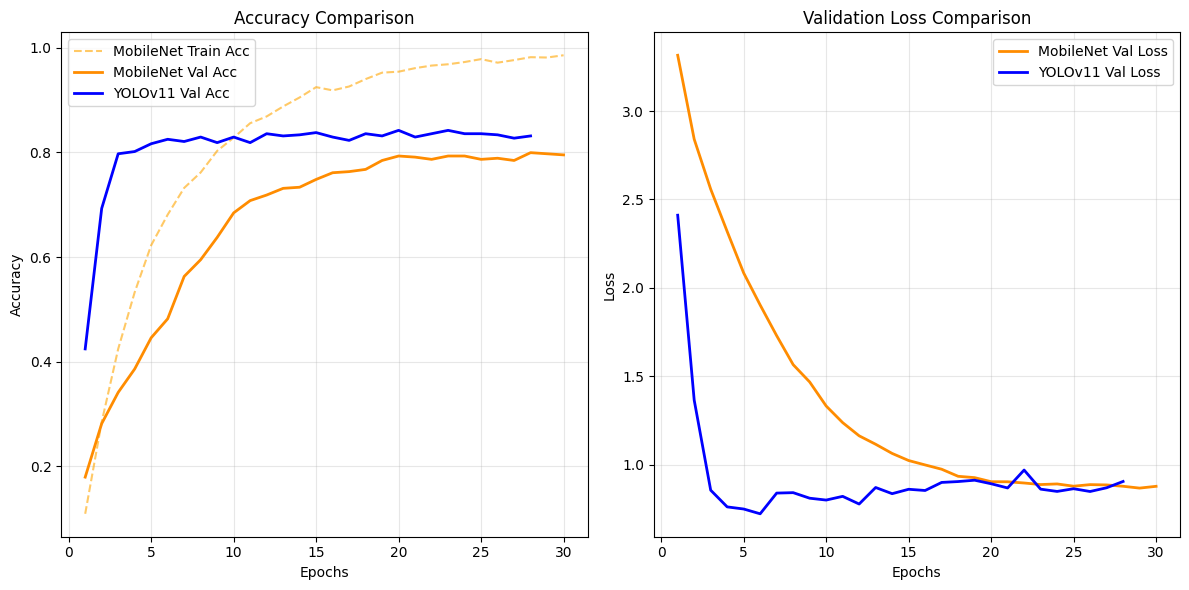

Found 237 images belonging to 30 classes.
Predicting with MobileNet...
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Predicting with YOLOv11...

PER-CLASS CLASSIFICATION REPORTS

--- YOLOv11 Report ---
                             precision    recall  f1-score   support

                       Aceh      0.500     0.400     0.444         5
                Bali_Barong      1.000     0.750     0.857         4
                 Bali_Merak      0.800     1.000     0.889         4
               Corak_Insang      1.000     0.889     0.941         9
                 Ikat_Celup      0.667     1.000     0.800         2
        Jakarta_Ondel_Ondel      1.000     1.000     1.000         3
     Jawa_Barat_Megamendung      0.917     1.000     0.957        22
           Jawa_Timur_Pring      0.833     1.000     0.909         5
           Kalimantan_Dayak      0.955     0.913     0.933        23
                    Keraton      0.200     0.500     0.286         2
              Lampung_Gajah      0.889     1.00

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Saved 'confusion_matrices_normalized.png' and 'training_comparison.png'


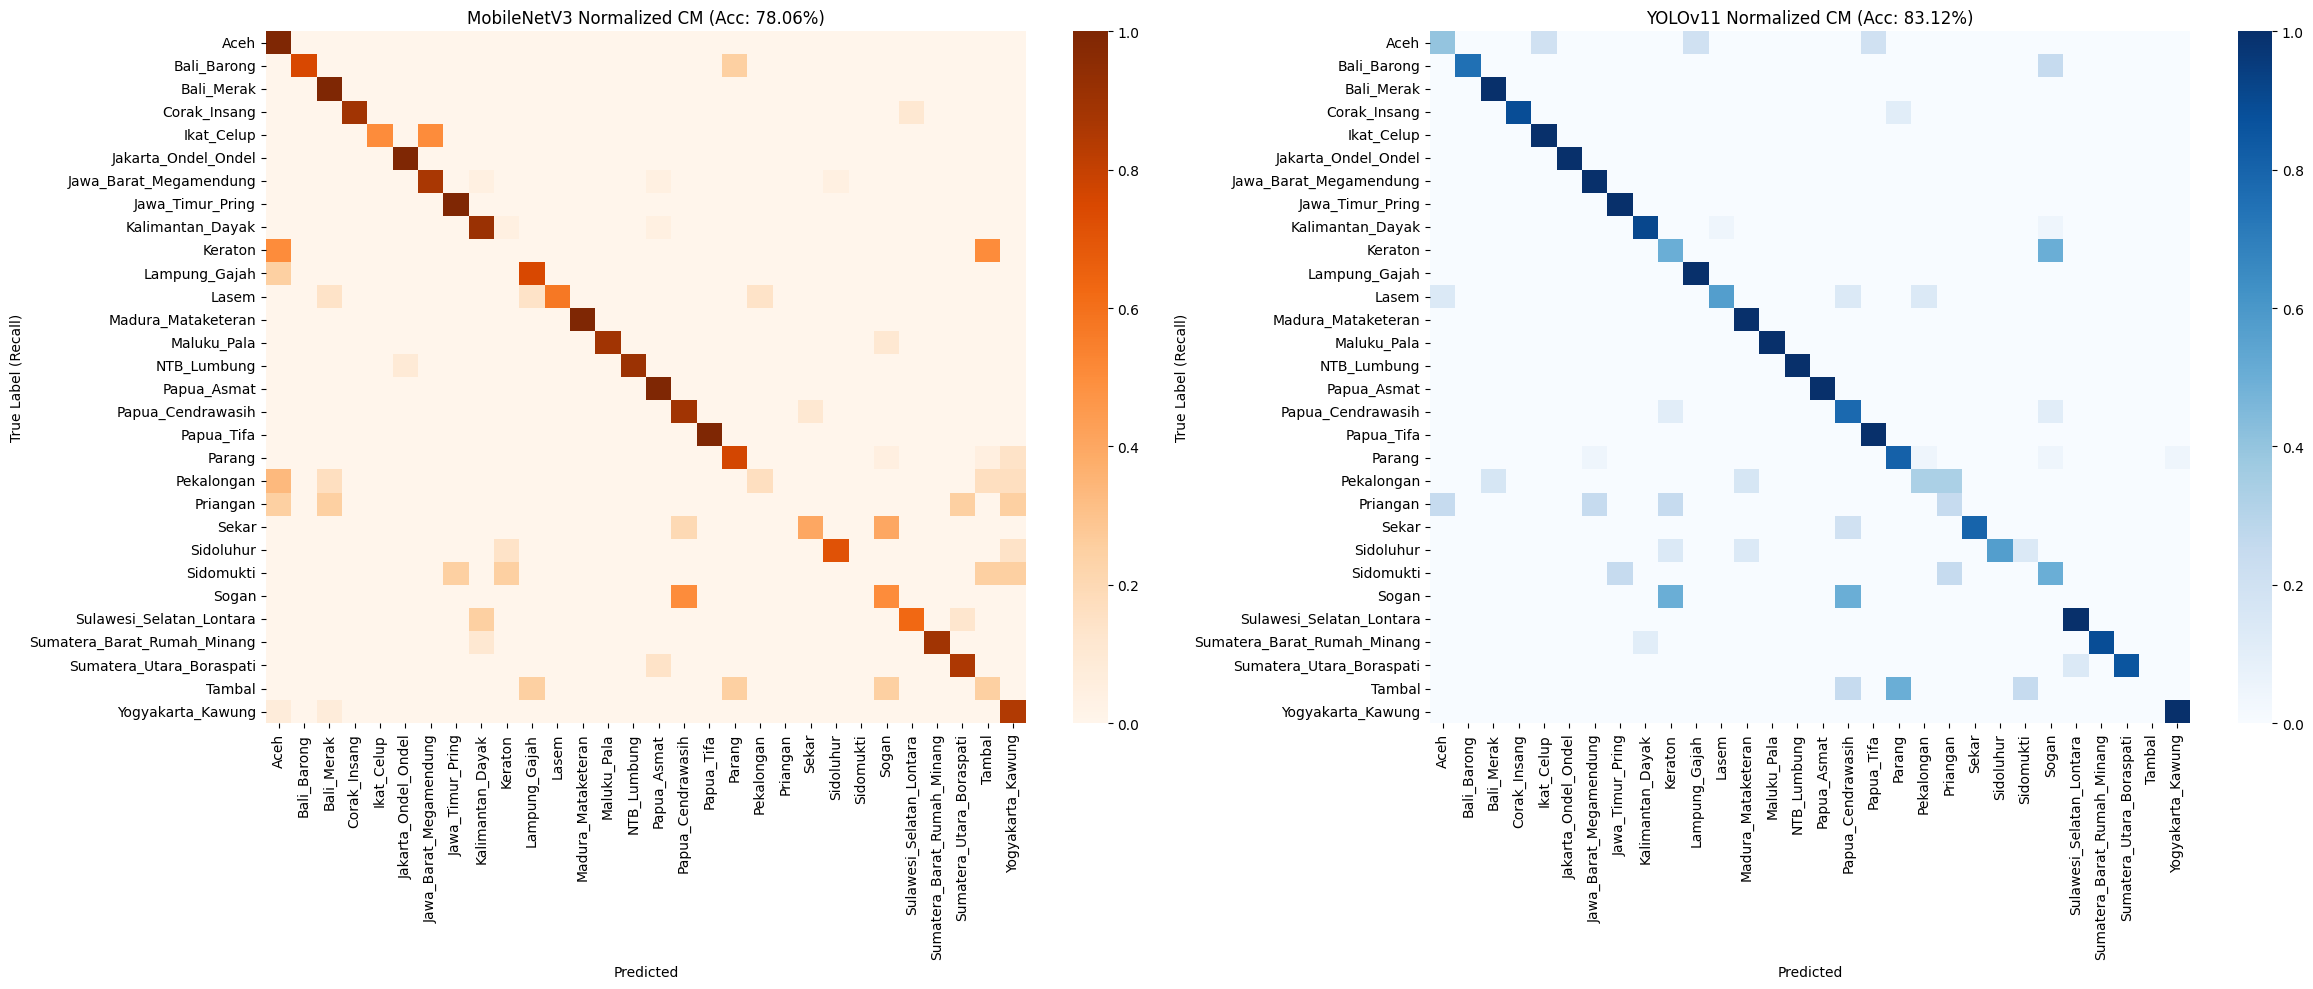

In [ ]:
from sklearn.metrics import confusion_matrix

print("\n" + "="*40)
print("EVALUATION & PLOTS")
print("="*40)

# Ultralytics writes per-epoch metrics to results.csv, Keras keeps them in
# history. Pulling both into dataframes so they can go on the same axes.
yolo_df = pd.read_csv(f"runs/classify/batik_comparison/yolo11_run/results.csv")
yolo_df.columns = [c.strip() for c in yolo_df.columns]  # ultralytics pads its headers with spaces
mn_df = pd.DataFrame(mn_history.history)
mn_df['epoch'] = range(1, len(mn_df) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(mn_df['epoch'], mn_df['accuracy'], linestyle='--', color='orange', alpha=0.6, label='MobileNet Train Acc')
plt.plot(mn_df['epoch'], mn_df['val_accuracy'], linewidth=2, color='darkorange', label='MobileNet Val Acc')
plt.plot(yolo_df['epoch'], yolo_df['metrics/accuracy_top1'], linewidth=2, color='blue', label='YOLOv11 Val Acc')
plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mn_df['epoch'], mn_df['val_loss'], linewidth=2, color='darkorange', label='MobileNet Val Loss')
plt.plot(yolo_df['epoch'], yolo_df['val/loss'], linewidth=2, color='blue', label='YOLOv11 Val Loss')
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_comparison.png")
plt.show()

# Test set. shuffle=False is important here, otherwise the generator's label
# order stops matching the prediction order and every metric comes out garbage.
test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Predicting with MobileNet...")
mn_preds_probs = mn_model.predict(test_generator)
mn_preds = np.argmax(mn_preds_probs, axis=1)

# feeding YOLO the generator's filepaths so both models score the exact same
# images in the exact same order
print("Predicting with YOLOv11...")
yolo_preds_raw = yolo_model.predict(test_generator.filepaths, verbose=False)
yolo_preds = [r.probs.top1 for r in yolo_preds_raw]

print("\n" + "="*40)
print("PER-CLASS CLASSIFICATION REPORTS")
print("="*40)

print("\n--- YOLOv11 Report ---")
print(classification_report(y_true, yolo_preds, target_names=class_labels, digits=3))

print("\n--- MobileNetV3 Report ---")
print(classification_report(y_true, mn_preds, target_names=class_labels, digits=3))

# weighted F1 on top of accuracy because the class counts are lopsided
mn_acc = accuracy_score(y_true, mn_preds)
yolo_acc = accuracy_score(y_true, yolo_preds)
mn_f1 = f1_score(y_true, mn_preds, average='weighted')
yolo_f1 = f1_score(y_true, yolo_preds, average='weighted')

print("\n" + "="*40)
print("FINAL TEST RESULTS")
print("="*40)
results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Weighted F1-Score", "Training Time (min)"],
    "YOLOv11-Medium": [yolo_acc, yolo_f1, yolo_train_time],
    "MobileNetV3-Large": [mn_acc, mn_f1, mn_train_time]
})
print(results_df.to_markdown(index=False))

# Row-normalised so each row reads as recall for that motif. Raw counts would
# just make Parang look impressive because it has the most test images.
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

cm_mn = confusion_matrix(y_true, mn_preds, normalize='true')
sns.heatmap(cm_mn, annot=False, cmap='Oranges', xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title(f"MobileNetV3 Normalized CM (Acc: {mn_acc:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True Label (Recall)")
axes[0].tick_params(axis='x', rotation=90)

cm_yolo = confusion_matrix(y_true, yolo_preds, normalize='true')
sns.heatmap(cm_yolo, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title(f"YOLOv11 Normalized CM (Acc: {yolo_acc:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True Label (Recall)")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig("confusion_matrices_normalized.png")
print("\nSaved 'confusion_matrices_normalized.png' and 'training_comparison.png'")
plt.show()